In [1532]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

In [1533]:
df=pd.read_csv("train.csv")
display(df)
og_df = df.copy()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


In [1534]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [1535]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [1536]:
df["carID"].duplicated().any()
#não há IDs duplicados então vou troná-los em indices

np.False_

In [1537]:
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


In [1538]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

In [1539]:
df["Brand"].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [1540]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [1541]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )
    
    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [1542]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

In [1543]:
df["Brand"].value_counts()

Brand
Ford        16063
Mercedes    11674
VW          10385
Opel         9352
BMW          7392
Audi         7325
Toyota       4622
Skoda        4303
Hyundai      3336
Name: count, dtype: int64

In [1544]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [1545]:
len(df["model"].unique())

736

In [1546]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])


model
 Tucson      821
 I10         671
 I30         352
 I20         307
 Kona        213
 Ioniq       185
 Santa Fe    135
 IX20        129
 I40          78
 IX35         74
 I800         72
 i10          20
 Tucso        18
 TUCSON       17
 tucson       16
 I1           15
Tucson        15
I10           13
 I3            9
 Santa F       8
 i30           8
 Ioni          7
 i20           7
 Getz          6
Ioniq          6
Kona           6
I20            5
I30            5
 I2            4
 SANTA FE      4
 I80           3
 IX2           3
 ix20          3
 kona          3
 santa fe      3
Santa Fe       3
 IONIQ         2
 KONA          2
 Kon           2
 ix35          2
IX20           2
IX35           2
 Accent        1
 KON           1
 TUCSO         1
 Terracan      1
 Veloste       1
 i40           1
 ioniq         1
I40            1
IONIQ          1
Tucso          1
Name: count, dtype: int64

In [1547]:
"""Optained through meticulous ChatGPT prompt engineering"""
valid_models = {
    "Audi": [
        "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
        "Q2", "Q3", "Q5", "Q7", "Q8",
        "TT", "T", "R8",
        "S3", "S4", "S5", "S8",
        "RS3", "RS4", "RS5", "RS6",
        "SQ5", "SQ7"
    ],

    "Ford": [
        "FOCUS", "FIESTA", "MONDEO", "KA", "KA+", "FUSION",
        "KUGA", "ECOSPORT", "EDGE", "PUMA",
        "CMAX", "BMAX", "SMAX", "GALAXY",
        "GRANDCMAX", "TOURNEOCONNECT", "GRANDTOURNEOCONNECT", "TOURNEOCUSTOM",
        "MUSTANG", "RANGER", "ESCORT", "STREETKA"
    ],

    "Mercedes": [
        "ACLASS", "BCLASS", "CCLASS", "ECLASS", "SCLASS",
        "GLA", "GLB", "GLC", "GLE", "GLS", "GCLASS", "GLCLASS", "MCLASS",
        "CLA", "CLS", "SL", "SLK", "CLK",
        "VCLASS", "XCLASS", "CLC"
    ],

    "VW": [
        "GOLF", "POLO", "PASSAT", "JETTA", "ARTEON", "SCIROCCO", "BEETLE",
        "UP", "GOL", "FOX",
        "TIGUAN", "TIGUANALLSPACE", "TROC", "TCROSS", "TOUAREG",
        "TOURAN", "SHARAN", "CADDY", "CADDYMAXI", "CADDYMAXILIFE",
        "CARAVELLE", "CALIFORNIA", "SHUTTLE",
        "AMAROK", "GOLFSV", "CC"
    ],

    "Opel": [
        "CORSA", "ASTRA", "INSIGNIA", "VECTRA",
        "MOKKA", "MOKKAX", "CROSSLAND", "CROSSLANDX",
        "GRANDLAND", "GRANDLANDX", "ANTARA",
        "ZAFIRA", "ZAFIRATOURER", "MERIVA", "COMBOLIFE", "VIVARO",
        "ADAM", "AGILA", "VIVA",
        "TIGRA", "GTC", "CASCADA", "AMPERA"
    ],

    "BMW": [
        "1SERIES", "2SERIES", "3SERIES", "4SERIES",
        "5SERIES", "6SERIES", "7SERIES", "8SERIES",
        "X1", "X2", "X3", "X4", "X5", "X6", "X7",
        "M2", "M3", "M4", "M5", "M6",
        "Z3", "Z4",
        "I3", "I4", "I8"
    ],

    "Toyota": [
        "YARIS", "AYGO", "AURIS", "COROLLA", "AVENSIS", "CAMRY", "PRIUS",
        "CHR", "RAV4", "LANDCRUISER", "URBANCRUISER",
        "VERSO", "VERSOS", "PROACEVERSO",
        "HILUX", "GT86", "SUPRA", "IQ"
    ],

    "Skoda": [
        "FABIA", "OCTAVIA", "SUPERB", "RAPID", "SCALA",
        "KODIAQ", "KAROQ", "KAMIQ", "YETI", "YETIOUTDOOR",
        "CITIGO", "ROOMSTER"
    ],

    "Hyundai": [
        "I10", "I20", "I30", "I40", "ACCENT", "GETZ",
        "KONA", "TUCSON", "SANTAFE", "IX20", "IX35",
        "I800", "IONIQ", "VELOSTER", "TERRACAN"
    ]
}


In [1548]:
def HELPER_normalize_models(df):
    df = df.copy()
    
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df


In [1549]:
def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model
    
    # Skip unknown brands
    if brand not in valid_models_dict:
        return model
    
    valid_list = valid_models_dict[brand]

    result = process.extractOne(
        model,
        valid_list,
        scorer=fuzz.token_sort_ratio
    )

    if result is None:
        return model    

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=60):
    df = HELPER_normalize_models(df)
    
    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df


In [1550]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [1551]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [1552]:
df=fuzzy_modelos(df, valid_models)
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [1553]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        26
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          26
Name: model, dtype: int64


In [1554]:
def inferir_marca_com_modelo(df, valid_models_dict):
    df = df.copy()

 # Build a mapping of models → their most frequent (mode) brand in the dataset
    model_to_brand = (
        df[df["Brand"].notna()]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
        .to_dict()
    )

    df["Brand"] = df.apply(
    lambda row: (
        row["Brand"]
        if pd.notna(row["Brand"])
        else model_to_brand.get(row["model"], None)
    ),
    axis=1
    )

    return df


In [1555]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,TROC,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,GOLF,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [1556]:
df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
45338,None,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
16342,None,None,2017.0,8600,MANUAL,28820.0,Diesel,0.0,74.4,1.5,NaN,0.0,0.0
38054,None,CLSCLASS,2018.0,31026,Automatic,17663.0,Diesel,145.0,48.7,2.9,94.0,0.0,0.0
12064,None,None,2018.0,21300,Automatic,11258.0,NaN,145.0,64.2,2.0,60.0,3.0,0.0
44351,None,None,2013.0,12990,Automatic,43000.0,Diesel,145.0,54.3,2.1,78.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68226,None,None,2017.0,10491,Manual,22211.0,Petrol,150.0,60.1,1.2,82.0,0.0,0.0
4703,None,None,2019.0,51990,Automatic,10.0,Petrol,NaN,30.4,2.9,54.0,1.0,0.0
41846,None,GLCCLASS,2019.0,31400,Semi-Auto,7670.0,Diesel,145.0,44.8,2.0,60.0,3.0,0.0


In [1557]:
df

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,YARIS,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2SERIES,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,AYGO,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


In [1558]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [1559]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [1560]:
old_cars = df[df["year"] < 2000][["Brand", "model", "year"]]
display(old_cars)
#os carros de 1970 nem existiam em 1970

,Brand,model,year
carID,,,
25881,Ford,ESCORT,1996.0
3908,Audi,A3,1998.0
62732,Opel,ZAFIRA,1970.0
13422,BMW,Z3,1999.0
36128,Mercedes,SLK,1998.0
51800,Toyota,YARIS,1999.0
34918,Mercedes,SCLASS,1997.0
52914,Toyota,LANDCRUISER,1998.0
35769,Mercedes,MCLASS,1970.0


In [1561]:
def limpar_anos(df):
    df = df.copy()

    df["year"] = np.round(df["year"]).astype("float")
    df.loc[(df["year"] < 1980) | (df["year"] > 2025),"year"] = np.nan
    return df

In [1562]:
df = limpar_anos(df)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [1563]:
df["year"].unique()

array([2016., 2019., 2018., 2014., 2017., 2020., 2013.,   nan, 2015.,
       2023., 2011., 2012., 2003., 2009., 2007., 2005., 2024., 2004.,
       2010., 2008., 2006., 2001., 2000., 2002., 1996., 1998., 1999.,
       1997.])

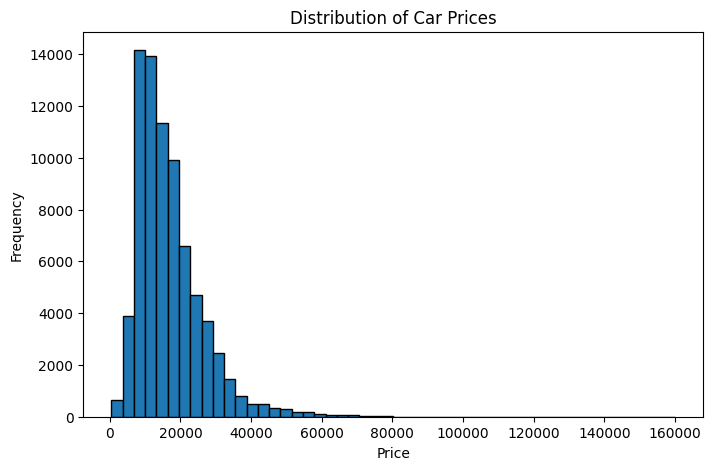

In [1564]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [1565]:
df["price"].describe()

count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

In [1566]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)
#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003.0,450
19562,Ford,FOCUS,2003.0,495
23427,Ford,FOCUS,2003.0,495
61005,Opel,CORSA,2002.0,495
55950,Opel,CORSA,2003.0,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003.0,450
19562,Ford,FOCUS,2003.0,495
23427,Ford,FOCUS,2003.0,495
61005,Opel,CORSA,2002.0,495
55950,Opel,CORSA,2003.0,590


In [1567]:
def preco_no_fim(df):
    df = df.copy()

    df = df[[col for col in df.columns if col != "price"] + ["price"]]
    return df

In [1568]:
df=preco_no_fim(df)
df

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0,22290
53000,Toyota,YARIS,2019.0,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0,13790
6366,Audi,Q2,2019.0,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0,24990
29021,Ford,FIESTA,2018.0,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0,12500
10062,BMW,2SERIES,2019.0,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0,22995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0,13498
6265,Audi,Q3,2013.0,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0,12495
54886,Toyota,AYGO,2017.0,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0,8399


In [1569]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [1570]:
df[df["transmission"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0,26176
35376,Mercedes,CCLASS,2015.0,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0,16998
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0,6995
68423,VW,POLO,NaN,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0,10328
47887,Skoda,FABIA,2020.0,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0,11990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019.0,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0,19990
12874,BMW,4SERIES,2019.0,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0,29995
1016,Audi,Q5,2016.0,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0,22995


In [1571]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [1572]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm
    
    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

In [1573]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0,26176
35376,Mercedes,CCLASS,2015.0,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0,16998
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0,6995
68423,VW,POLO,NaN,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0,10328
47887,Skoda,FABIA,2020.0,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0,11990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019.0,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0,19990
12874,BMW,4SERIES,2019.0,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0,29995
1016,Audi,Q5,2016.0,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0,22995


In [1574]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

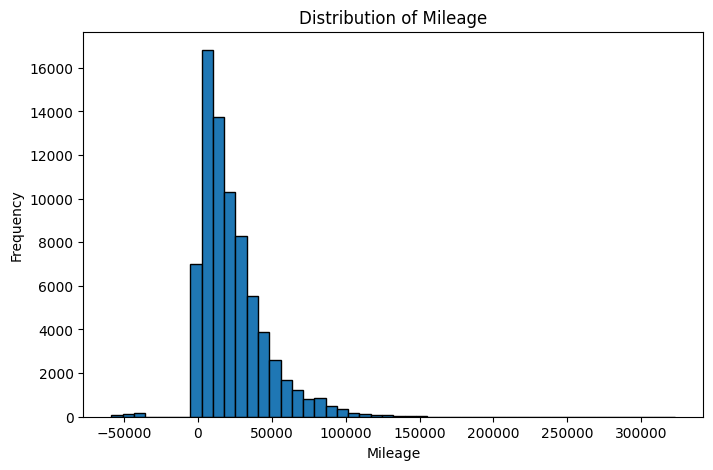

In [1575]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

In [1576]:
df[df["mileage"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0,6995
41441,Mercedes,ACLASS,2017.0,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0,13500
22269,Ford,FIESTA,2017.0,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0,8930
6409,Audi,A1,2016.0,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0,10999
7725,BMW,X2,2019.0,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0,23633
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,2019.0,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0,18390
55680,Toyota,CHR,2017.0,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0,20700
39353,Mercedes,GLCLASS,2019.0,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0,36490


In [1577]:
df[df["mileage"] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,2020.0,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0,25000
43529,Mercedes,CCLASS,2019.0,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0,25780
71090,VW,GOLF,2018.0,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0,14995
7845,BMW,3SERIES,2019.0,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0,23498
24999,Ford,FIESTA,2017.0,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0,8895
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2018.0,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN,8514
45765,Mercedes,GLCLASS,2020.0,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0,54995
38413,Mercedes,SLK,2015.0,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0,17900


In [1578]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

In [1579]:
df=impossible_to_nan(df, "mileage")
df.loc[70615]

Brand                 VW
model             TIGUAN
year              2020.0
transmission      MANUAL
mileage              NaN
fuelType          Petrol
tax                145.0
mpg                 38.2
engineSize           1.5
paintQuality%       89.0
previousOwners       3.0
hasDamage            0.0
price              25000
Name: 70615, dtype: object

In [1580]:
df[df["mileage"] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,


In [1581]:
df[df["mileage"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0,6995
41441,Mercedes,ACLASS,2017.0,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0,13500
22269,Ford,FIESTA,2017.0,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0,8930
6409,Audi,A1,2016.0,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0,10999
7725,BMW,X2,2019.0,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0,23633
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,2019.0,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0,36490
9474,BMW,3SERIES,2016.0,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0,14000
55820,Toyota,AYGO,2019.0,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0,8491


In [1582]:
df["fuelType"].unique()

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

In [1583]:
df[df["fuelType"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
831,Audi,A8,2017.0,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0,38995
49731,Skoda,OCTAVIA,NaN,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0,11990
1272,Audi,Q7,2017.0,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0,53990
36753,Mercedes,SCLASS,2017.0,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0,18990
53403,Toyota,AYGO,2016.0,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0,7995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015.0,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0,8599
30306,Ford,FIESTA,2017.0,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0,8499
30535,Ford,FIESTA,2016.0,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0,8990


In [1584]:
df["fuelType"].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

In [1585]:
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [1586]:
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel
    
    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df

In [1587]:
df=fuzzy_fuel(df)
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [1588]:
df[df["fuelType"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
831,Audi,A8,2017.0,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0,38995
49731,Skoda,OCTAVIA,NaN,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0,11990
1272,Audi,Q7,2017.0,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0,53990
36753,Mercedes,SCLASS,2017.0,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0,18990
53403,Toyota,AYGO,2016.0,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0,7995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015.0,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0,8599
30306,Ford,FIESTA,2017.0,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0,8499
30535,Ford,FIESTA,2016.0,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0,8990


In [1589]:
df["fuelType"].value_counts()

fuelType
PETROL      41181
DIESEL      30885
HYBRID       2225
OTHER         167
ELECTRIC        4
Name: count, dtype: int64

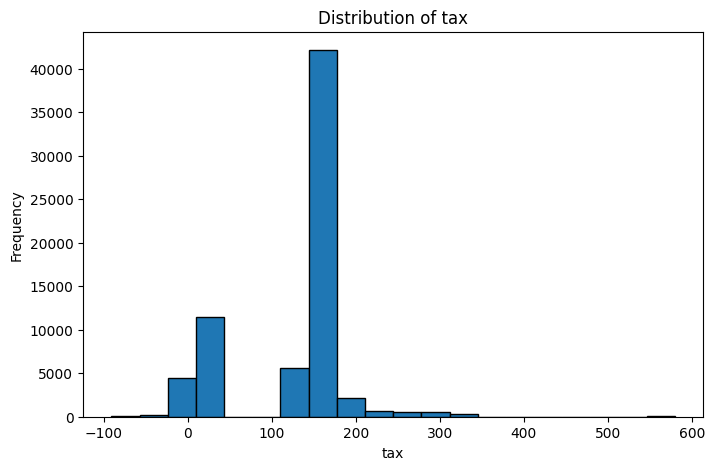

In [1590]:
plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [1591]:
df[df["tax"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0,22290
20142,Ford,FOCUS,2017.0,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0,18997
39796,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0,31299
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0,26176
35004,Mercedes,CCLASS,2016.0,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0,21499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017.0,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0,17000
40757,Mercedes,CCLASS,2019.0,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0,28980
19457,Ford,FOCUS,2019.0,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0,18910


In [1592]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

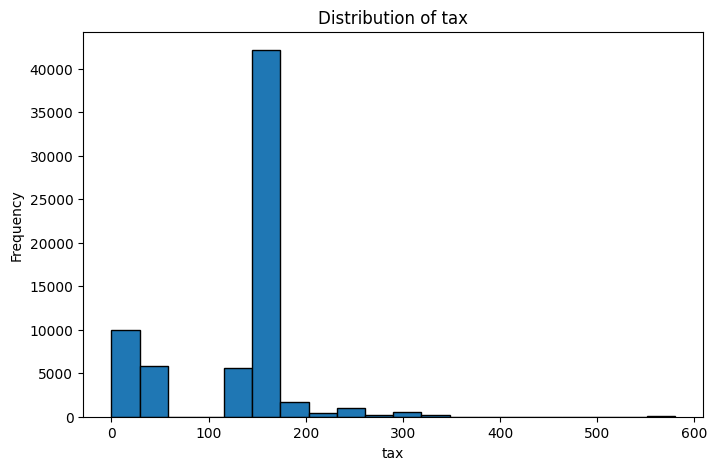

In [1593]:
df=impossible_to_nan(df, "tax")

plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [1594]:
df[df["tax"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0,22290
20142,Ford,FOCUS,2017.0,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0,18997
39796,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0,31299
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0,26176
35263,Mercedes,CCLASS,NaN,AUTOMATIC,45000.0,PETROL,NaN,46.300000,1.6,59.0,NaN,0.0,11295
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017.0,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0,17000
40757,Mercedes,CCLASS,2019.0,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0,28980
19457,Ford,FOCUS,2019.0,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0,18910


In [1595]:
g = df[df["tax"] == 0]
g["year"].value_counts()

year
2016.0    1675
2017.0    1046
2015.0     827
2014.0     391
2013.0     221
2012.0      26
2011.0      16
2023.0      16
2010.0      15
2009.0       5
2024.0       3
2018.0       2
Name: count, dtype: int64

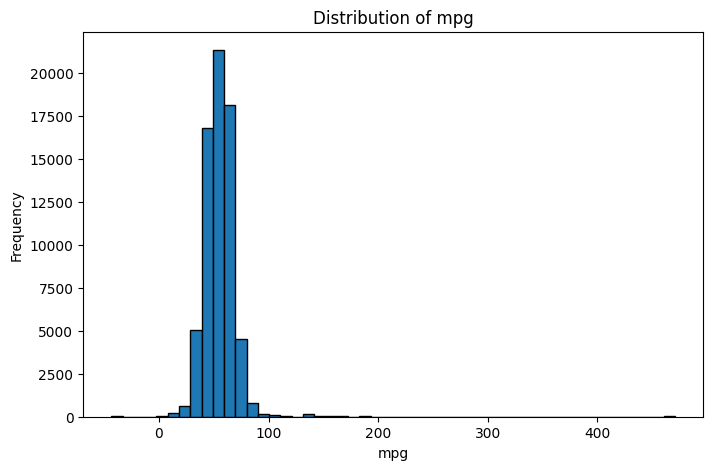

In [1596]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()
#FIXE

In [1597]:
df[df["mpg"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017.0,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0,18997
39796,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0,31299
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0,26176
35004,Mercedes,CCLASS,2016.0,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0,21499
19811,Ford,FOCUS,2019.0,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0,17990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017.0,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0,17000
1016,Audi,Q5,2016.0,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0,22995
40757,Mercedes,CCLASS,2019.0,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0,28980


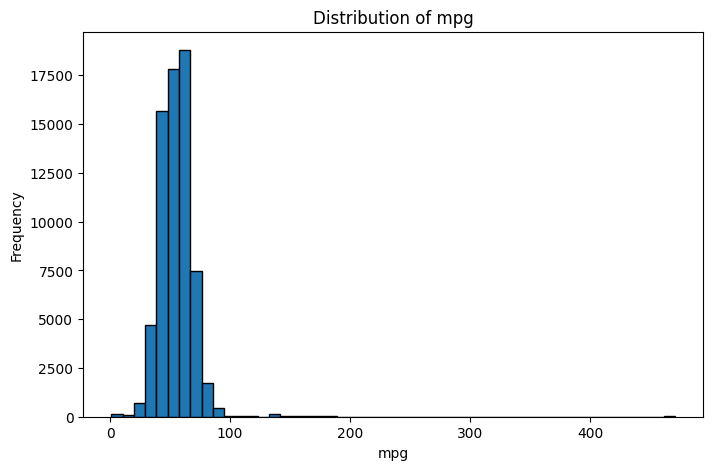

In [1598]:
df=impossible_to_nan(df, "mpg")

plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [1599]:
df[df["mpg"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017.0,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0,18997
39796,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0,31299
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0,26176
35004,Mercedes,CCLASS,2016.0,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0,21499
19811,Ford,FOCUS,2019.0,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0,17990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017.0,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0,17000
1016,Audi,Q5,2016.0,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0,22995
40757,Mercedes,CCLASS,2019.0,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0,28980


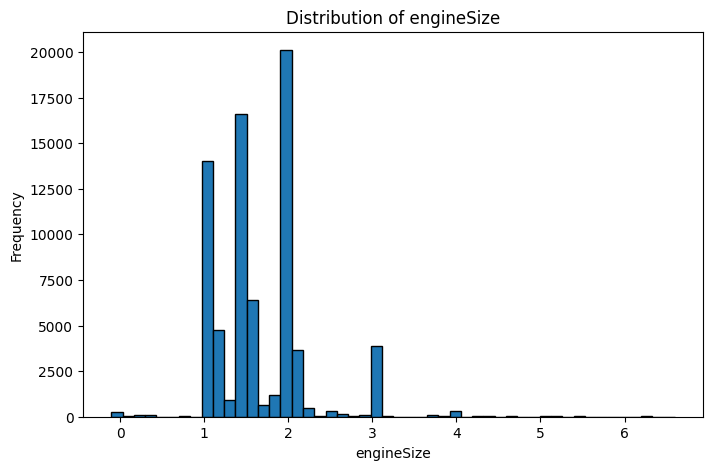

In [1600]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [1601]:
df[df["engineSize"] < 0.6]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0,9999
24113,Ford,KUGA,NaN,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0,14950
3840,Audi,None,2019.0,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0,21262
21935,Ford,KA,2018.0,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0,8444
9518,BMW,2SERIES,2015.0,AUTOMATIC,32882.0,DIESEL,125.0,60.1,0.000000,55.0,0.0,0.0,14700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33307,Hyundai,I10,2018.0,MANUAL,12948.0,PETROL,145.0,60.1,0.000000,46.0,2.0,0.0,8500
46732,Skoda,OCTAVIA,2018.0,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0,11290
38494,Mercedes,GLCLASS,2016.0,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0,19498


In [1602]:
df[df["engineSize"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019.0,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0,13295
38898,Mercedes,GLCLASS,2017.0,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0,28995
54844,Toyota,AYGO,2017.0,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0,7299
57086,Opel,INSIGNIA,2017.0,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0,7695
70418,VW,GOLF,2016.0,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0,16898
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,2019.0,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0,14999
61373,Opel,ASTRA,2017.0,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0,10800
68148,VW,GOLF,2020.0,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0,20769


In [1603]:
df=impossible_to_nan(df, "engineSize", 0.6)
df[df["engineSize"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019.0,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0,13295
38898,Mercedes,GLCLASS,2017.0,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0,28995
30317,Ford,None,2019.0,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0,9999
54844,Toyota,AYGO,2017.0,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0,7299
57086,Opel,INSIGNIA,2017.0,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0,7695
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,2015.0,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0,9995
68148,VW,GOLF,2020.0,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0,20769
10627,BMW,3SERIES,2020.0,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0,24990


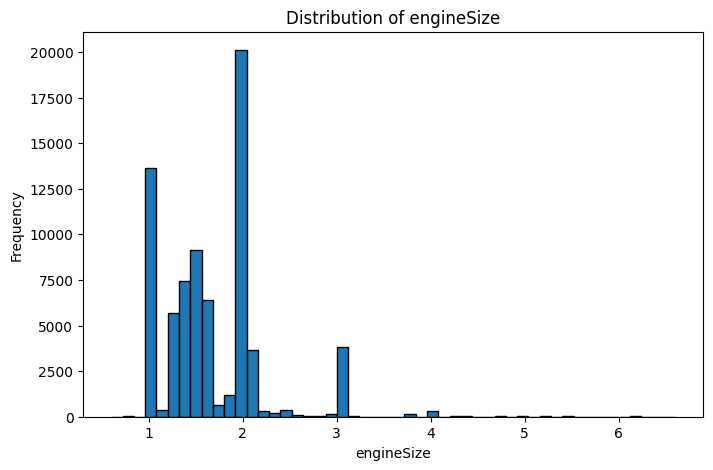

In [1604]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [1605]:
df["paintQuality%"].describe()

count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64

In [1606]:
df[df["paintQuality%"] > 100]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
15717,Ford,FIESTA,2018.0,MANUAL,6522.0,PETROL,145.0,65.7,1.0,125.109951,3.0,0.0,10491
11200,BMW,4SERIES,2019.0,SEMI-AUTO,6100.0,PETROL,145.0,45.6,2.0,125.569499,2.0,0.0,23591
53403,Toyota,AYGO,2016.0,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.0,0.0,7995
48038,Skoda,YETIOUTDOOR,2015.0,SEMI-AUTO,19805.0,PETROL,125.0,51.4,1.2,125.453599,1.0,0.0,11995
10137,BMW,5SERIES,2017.0,AUTOMATIC,18820.0,DIESEL,145.0,65.7,2.0,125.569499,4.0,0.0,21995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75768,VW,TIGUAN,2018.0,MANUAL,24940.0,PETROL,145.0,48.7,1.4,125.366507,0.0,0.0,18499
39666,Mercedes,ECLASS,2017.0,SEMI-AUTO,40690.0,DIESEL,145.0,NaN,3.0,125.202033,3.0,0.0,21602
23930,Ford,FIESTA,2020.0,MANUAL,35.0,PETROL,145.0,56.5,1.0,125.109951,0.0,0.0,15000


In [1607]:
df[df["paintQuality%"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016.0,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0,7991
25484,Ford,BMAX,2016.0,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0,9498
41801,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0,49499
55579,Toyota,YARIS,2019.0,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0,11280
55572,Toyota,AYGO,2019.0,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0,10195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013.0,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0,6698
62623,Opel,MOKKAX,2019.0,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN,14995
64505,Opel,CORSA,2016.0,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0,6999


In [1608]:
df = impossible_to_nan(df,"paintQuality%", 100, "upper")
df[df["paintQuality%"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016.0,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0,7991
25484,Ford,BMAX,2016.0,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0,9498
41801,Mercedes,CCLASS,2019.0,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0,49499
55579,Toyota,YARIS,2019.0,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0,11280
55572,Toyota,AYGO,2019.0,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0,10195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013.0,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0,6698
62623,Opel,MOKKAX,2019.0,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN,14995
64505,Opel,CORSA,2016.0,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0,6999


In [1609]:
df["paintQuality%"].describe()

count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64

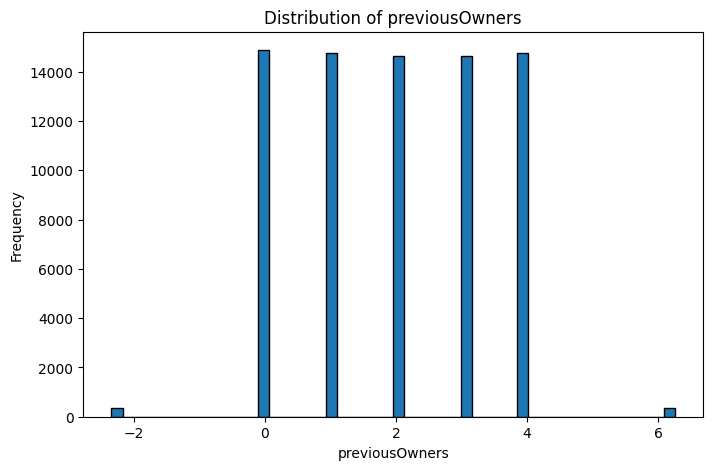

In [1610]:
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of previousOwners")
plt.xlabel("previousOwners")
plt.ylabel("Frequency")
plt.show()

In [1611]:
df["previousOwners"].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [1612]:
df[df["previousOwners"]<0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
29021,Ford,FIESTA,2018.0,MANUAL,9102.0,PETROL,145.0,65.7,1.0,50.0,-2.340306,0.0,12500
71677,VW,TIGUAN,2019.0,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,42.0,-2.345650,0.0,29999
16962,Ford,FOCUS,2019.0,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,41.0,-2.340306,0.0,19950
5994,Audi,None,2020.0,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,98.0,-2.335123,0.0,31990
5038,Audi,RS6,2020.0,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,72.0,-2.335123,0.0,97500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,2020.0,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,62.0,-2.345650,0.0,20998
75599,VW,UP,2015.0,MANUAL,10800.0,PETROL,20.0,61.4,1.0,31.0,-2.345650,0.0,6795
28295,Ford,SMAX,2017.0,MANUAL,28280.0,PETROL,145.0,43.5,1.5,45.0,-2.340306,0.0,17950


In [1613]:
df[df["previousOwners"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,59.0,NaN,0.0,11295
18304,Ford,None,2016.0,MANUAL,18814.0,PETROL,20.0,62.8,1.0,74.0,NaN,0.0,9632
49135,Skoda,SCALA,2020.0,MANUAL,731.0,PETROL,150.0,50.4,1.0,88.0,NaN,0.0,17000
37446,Mercedes,CCLASS,2019.0,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,87.0,NaN,0.0,27099
1768,Audi,Q3,2020.0,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,48.0,NaN,NaN,35990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,2014.0,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,57.0,NaN,0.0,19499
6295,Audi,A3,2018.0,MANUAL,6350.0,PETROL,150.0,55.4,1.5,60.0,NaN,0.0,17650
21918,Ford,FIESTA,2019.0,MANUAL,10576.0,PETROL,145.0,58.9,1.0,65.0,NaN,0.0,13998


In [1614]:
def round_owners_int(df):
    df=df.copy()

    df['previousOwners'] = df['previousOwners'].round().astype('Int64')
    return df

In [1615]:
df=impossible_to_nan(df,"previousOwners")
df=round_owners_int(df)
df["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [1616]:
df["hasDamage"].unique() #está cheia de zeros

array([ 0., nan])

In [1617]:
def remove_hasdmg(df):
    df = df.copy()

    df = df.drop(columns=['hasDamage'])
    return df

In [1618]:
df=remove_hasdmg(df)

In [1619]:
display(df)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,price
carID,,,,,,,,,,,,
69512,VW,GOLF,2016.0,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4,22290
53000,Toyota,YARIS,2019.0,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1,13790
6366,Audi,Q2,2019.0,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4,24990
29021,Ford,FIESTA,2018.0,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>,12500
10062,BMW,2SERIES,2019.0,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3,22995
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0,13498
6265,Audi,Q3,2013.0,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2,12495
54886,Toyota,AYGO,2017.0,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3,8399


In [1620]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

# Display the result
print("Missing Values with Percentage:\n")
print(missing_df)



Missing Values with Percentage:

                Missing Count  Missing Percentage
tax                      8282           10.901241
mpg                      7962           10.480039
engineSize               2034            2.677267
previousOwners           1921            2.528530
paintQuality%            1891            2.489042
mileage                  1832            2.411383
model                    1525            2.007292
transmission             1522            2.003343
fuelType                 1511            1.988864
year                     1493            1.965172
Brand                     104            0.136891


In [ ]:
def clean_df(df, valid_models):
    df=df.copy()

    df=carID_como_index(df)
    df=fuzzy_marcas(df)
    df=fuzzy_modelos(df, valid_models)
    df=inferir_marca_com_modelo(df, valid_models)
    df=limpar_anos(df)
    df=preco_no_fim(df)
    df=fuzzy_transmissao(df)
    df=impossible_to_nan(df, "mileage")
    df=fuzzy_fuel(df)
    df=impossible_to_nan(df, "tax")
    df=impossible_to_nan(df, "mpg")
    df=impossible_to_nan(df, "engineSize", 0.6)
    df=impossible_to_nan(df,"paintQuality%", 100, "upper")
    df=impossible_to_nan(df,"previousOwners")
    df=round_owners_int(df)
    df=remove_hasdmg(df)

    return df

In [1623]:
og_df=clean_df(og_df, valid_models)

In [1625]:
assert pd.testing.assert_frame_equal(df, og_df) is None